In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Default = pd.read_csv("data/data_2359.csv", index_col=0)

# Correlation plot

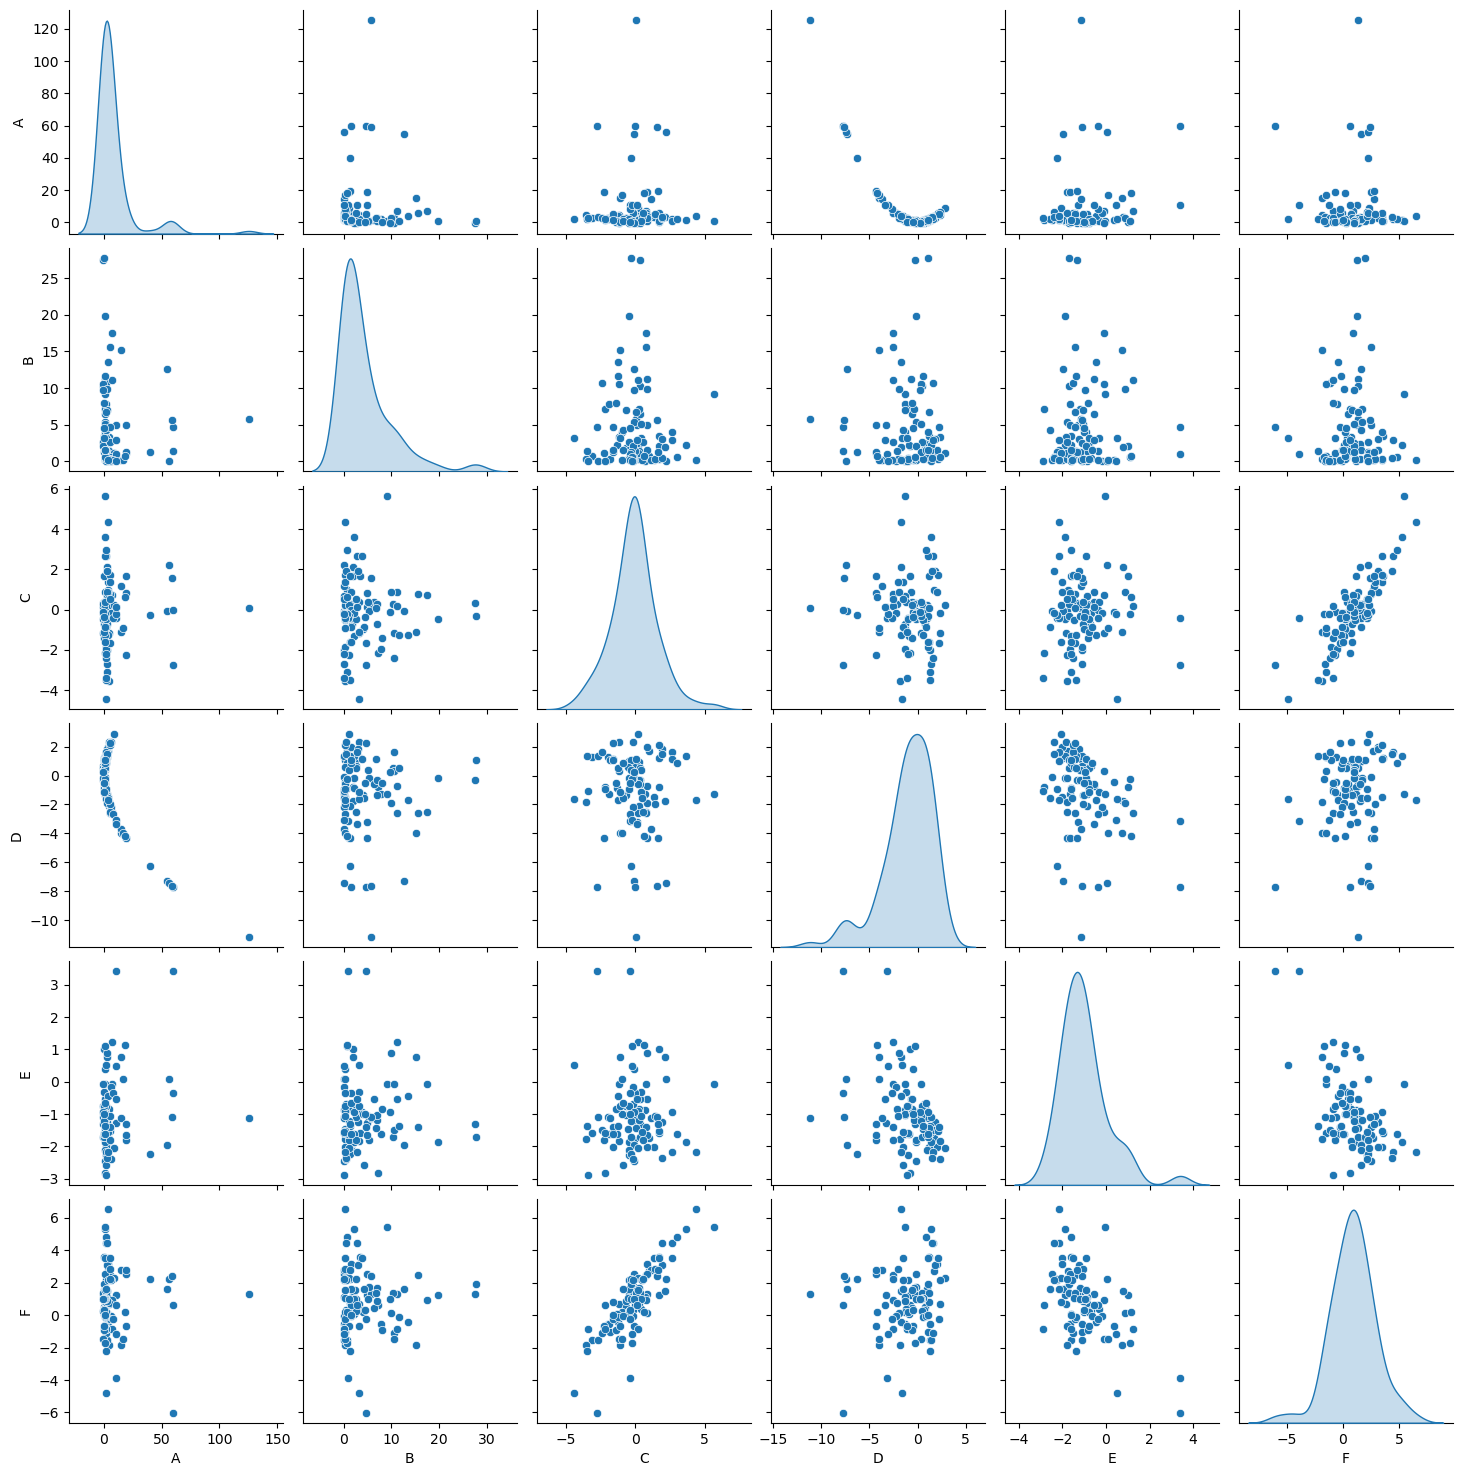

In [ ]:
sns.pairplot(Default, diag_kind="kde")
plt.show()

# Pearson Correlations to find hypothesis on which correlates

In [4]:
corr_matrix = Default.corr(method='pearson')
print(corr_matrix)

          A         B         C         D         E         F
A  1.000000 -0.012535  0.037665 -0.815341  0.163203 -0.048157
B -0.012535  1.000000  0.001844 -0.042723  0.035314 -0.023833
C  0.037665  0.001844  1.000000 -0.041867 -0.001564  0.829739
D -0.815341 -0.042723 -0.041867  1.000000 -0.346385  0.151287
E  0.163203  0.035314 -0.001564 -0.346385  1.000000 -0.542485
F -0.048157 -0.023833  0.829739  0.151287 -0.542485  1.000000


In [6]:
import pandas as pd
from scipy.stats import pearsonr

cols = Default.columns

results = []

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        col1 = cols[i]
        col2 = cols[j]
        
        r, p = pearsonr(Default[col1], Default[col2])
        
        results.append({
            "Var1": col1,
            "Var2": col2,
            "Pearson_r": r,
            "p_value": p
        })

corr_df = pd.DataFrame(results)

# Sortér efter stærkeste korrelation
corr_df = corr_df.sort_values(by="Pearson_r", key=abs, ascending=False)
corr_df = corr_df.reset_index(drop=True)
print(corr_df)

   Var1 Var2  Pearson_r       p_value
0     C    F   0.829739  1.465622e-26
1     A    D  -0.815341  5.405399e-25
2     E    F  -0.542485  5.541829e-09
3     D    E  -0.346385  4.151618e-04
4     A    E   0.163203  1.047151e-01
5     D    F   0.151287  1.329645e-01
6     A    F  -0.048157  6.342261e-01
7     B    D  -0.042723  6.729886e-01
8     C    D  -0.041867  6.791785e-01
9     A    C   0.037665  7.098557e-01
10    B    E   0.035314  7.272344e-01
11    B    F  -0.023833  8.139240e-01
12    A    B  -0.012535  9.014887e-01
13    B    C   0.001844  9.854767e-01
14    C    E  -0.001564  9.876754e-01


# KS test and mean shift test on interventions to find direction

In [20]:
import pandas as pd
from scipy.stats import ks_2samp, ttest_ind
import numpy as np

variables = ["A", "B", "C", "D", "E", "F"]

# Observational data
df_obs = pd.read_csv("data/data_2359.csv")

# Intervention datasets
interventions = {
    "A": {"value": -2, "df": pd.read_csv("data/A_-2.csv")},
    "B": {"value": -2, "df": pd.read_csv("data/B_-2.csv")},
    "C": {"value": -2, "df": pd.read_csv("data/C_-2.csv")},
    "D": {"value":  2, "df": pd.read_csv("data/D_2.csv")},
    "E": {"value":  2, "df": pd.read_csv("data/E_2.csv")},
    "F": {"value": -2, "df": pd.read_csv("data/F_-2.csv")},
}

pairs_of_interest = [
    ("A", "D"),
    ("D", "E"),
    ("E", "F"),
    ("C", "F")
]

rows = []

for source, info in interventions.items():
    df_int = info["df"]
    value = info["value"]

    for target in variables:
        if target == source:
            continue

        ks_stat, ks_p = ks_2samp(df_obs[target], df_int[target])
        t_stat, t_p = ttest_ind(df_obs[target], df_int[target], equal_var=False)

        rows.append({
            "intervention": f"do({source}={value})",
            "source": source,
            "target": target,
            "mean_obs": df_obs[target].mean(),
            "mean_int": df_int[target].mean(),
            "delta_mean": df_int[target].mean() - df_obs[target].mean(),
            "ks_stat": ks_stat,
            "ks_p": ks_p,
            "ks_significant": ks_p < 0.05,
            "t_stat": t_stat,
            "t_p": t_p,
            "mean_significant": t_p < 0.05
        })

effects = pd.DataFrame(rows)

# Kun retninger mellem jeres Pearson-hypotese-par
directed_tests = effects[
    effects.apply(
        lambda row: any(
            (row["source"] == x and row["target"] == y) or
            (row["source"] == y and row["target"] == x)
            for x, y in pairs_of_interest
        ),
        axis=1
    )
].sort_values(["source", "target"])
display(directed_tests)

,intervention,source,target,mean_obs,mean_int,delta_mean,ks_stat,ks_p,ks_significant,t_stat,t_p,mean_significant
2,do(A=-2),A,D,-1.048663,-1.244199,-0.195536,0.11,5.830091e-01,False,0.512600,6.088071e-01,False
14,do(C=-2),C,F,0.893610,-0.917185,-1.810795,0.58,6.689905e-16,True,7.815893,7.093304e-13,True
15,do(D=2),D,A,8.147203,4.325960,-3.821243,0.60,4.528308e-17,True,2.161944,3.302418e-02,True
18,do(D=2),D,E,-1.007950,-1.217468,-0.209517,0.15,2.111701e-01,False,1.387750,1.667806e-01,False
23,do(E=2),E,D,-1.048663,-1.178045,-0.129382,0.06,9.942356e-01,False,0.349458,7.271171e-01,False
24,do(E=2),E,F,0.893610,-2.045752,-2.939361,0.71,1.587524e-24,True,11.541391,1.277876e-23,True
27,do(F=-2),F,C,-0.104318,-0.178434,-0.074116,0.11,5.830091e-01,False,0.356647,7.217603e-01,False
29,do(F=-2),F,E,-1.007950,-0.922349,0.085602,0.12,4.695064e-01,False,-0.495278,6.209716e-01,False


# Undersøgelse af B

In [16]:
import pandas as pd
from scipy.stats import ks_2samp, ttest_ind

variables = ["A", "B", "C", "D", "E", "F"]

# Hvis ikke allerede loaded:
df_obs = pd.read_csv("data/data_2359.csv")
df_B = pd.read_csv("data/B_-2.csv")

rows = []

for target in variables:
    if target == "B":
        continue

    ks_stat, ks_p = ks_2samp(df_obs[target], df_B[target])
    t_stat, t_p = ttest_ind(df_obs[target], df_B[target], equal_var=False)

    rows.append({
        "possible_edge": f"B → {target}",
        "target": target,
        "mean_obs": df_obs[target].mean(),
        "mean_do_B": df_B[target].mean(),
        "delta_mean": df_B[target].mean() - df_obs[target].mean(),
        "ks_stat": ks_stat,
        "ks_p": ks_p,
        "ks_significant": ks_p < 0.05,
        "t_p": t_p,
        "mean_significant": t_p < 0.05
    })

B_effects = pd.DataFrame(rows).sort_values("ks_p")

alpha = 0.05
m = len(B_effects)

B_effects["bonferroni_alpha"] = alpha / m
B_effects["ks_significant_bonferroni"] = B_effects["ks_p"] < alpha / m
B_effects["t_significant_bonferroni"] = B_effects["t_p"] < alpha / m

display(B_effects)

,possible_edge,target,mean_obs,mean_do_B,delta_mean,ks_stat,ks_p,ks_significant,t_p,mean_significant,bonferroni_alpha,ks_significant_bonferroni,t_significant_bonferroni
0,B → A,A,8.147203,10.253858,2.106655,0.26,0.002220,True,0.411922,False,0.01,True,False
3,B → E,E,-1.007950,-1.323833,-0.315883,0.19,0.053902,False,0.028235,True,0.01,False,False
4,B → F,F,0.893610,1.266759,0.373149,0.14,0.281942,False,0.142663,False,0.01,False,False
2,B → D,D,-1.048663,-1.473033,-0.424370,0.13,0.368188,False,0.280678,False,0.01,False,False
1,B → C,C,-0.104318,-0.048659,0.055659,0.09,0.815415,False,0.796743,False,0.01,False,False


# Test at det ikke er A der peger på B

In [19]:
from scipy.stats import ks_2samp, ttest_ind

ks_stat, ks_p = ks_2samp(df_obs["B"], df_A["B"])
t_stat, t_p = ttest_ind(df_obs["B"], df_A["B"], equal_var=False)


if ks_p and t_p < 0.05:
    print("A points back at B")
else:
    print("A doesn't point at B")
    print ("Only B points at A") 


A doesn't point at B
Only B points at A
